# Functional Mapping (FM) Pipeline
This pipeline automates the transition from raw connectome data to high-dimensional functional activity maps. It quantifies how signals from specific sensory inputs propagate through the neural network across both brain hemispheres.

**Core Workflow:**

**Matrix Exporting:** Converts raw connection lists into compressed sparse matrices for high-performance computing.

**Functional Analysis:** Computes multi-step synaptic influence weights based on network topology, depth, and pruning thresholds.

**Visual Preprocessing:** Maps abstract neuronal weights onto biological spatial coordinates (columns) for anatomical visualization.

In [1]:
# -----------------------------
# 1. ENVIRONMENT SETUP
# -----------------------------
import sys
import os

sys.path.append(os.path.abspath('../util'))

from connectome_matrix import ConnectomeMatrixExporter
from FM_analyzer import FMAnalyzer
from show_VFM import VFMShow

In [2]:
# -----------------------------
# 2. DATA EXPORTING
# -----------------------------
# Initialized to convert raw connection files into Connectome Matrix
exporter = ConnectomeMatrixExporter(
        connections_path="../data/connections.txt",
        n_jobs=256,
        results_dir="preprocess"
    )

exporter.save_connectome_matrix_npy()

Computing connectome weights...


100%|██████████| 1024/1024 [00:22<00:00, 44.54it/s]



Sparse connectome matrix saved to: preprocess/connectome_matrix.npz
Neuron IDs saved to: preprocess/neuron_ids.npy
Text format saved to: preprocess/connectome_matrix.txt


In [ ]:
# -----------------------------
# 3. FUNCTIONAL WEIGHT COMPUTATION
# -----------------------------
# Configures the analyzer with exported matrices and neuron metadata
analyzer = FMAnalyzer(
    matrix_npz_path="./preprocess/connectome_matrix.npz",
    neuron_ids_path="./preprocess/neuron_ids.npy",
    neuron_types_path="../data/visual_neuron_types.txt"
)

params_right = {
    'neuron_types': {'L1','L2','L3'},   
    'side': 'right',                      
    'max_depth': 100,                     
    'min_weight': 1e-6,                   
    'num_processes': 256,                  
    'blocked_types': []       
}

params_left = {
    'neuron_types': {'L1','L2','L3'},   
    'side': 'left',                      
    'max_depth': 100,                     
    'min_weight': 1e-6,                   
    'num_processes': 256,                  
    'blocked_types': []       
}

# Independently compute functional maps for Right and Left brain hemispheres
analyzer.compute_and_save_weights(**params_left)
analyzer.compute_and_save_weights(**params_right)



Processing L2 neurons (with block=[])


Processing L2:  11%|█         | 91/848 [00:08<00:45, 16.78it/s]

In [2]:
# -----------------------------
# 4. VISUALIZATION PREPROCESSING
# -----------------------------

vfm_show = VFMShow("../data/column_assignment.txt")

# preprocess the neuron matrices for visualization
vfm_show.generate_all_matrices(
    neuron_types=['L1','L2','L3'],
    side="right",
    blocked_types=[],
)

vfm_show.generate_all_matrices(
    neuron_types=['L1','L2','L3'],
    side="left",
    blocked_types=[],
)


Processing all layers for right hemisphere (PyTorch accelerated)...
Using device: cuda

Processing layer l1...

Processing layer l2...

Processing layer l3...

Saving output...
All raster matrices saved (no centering).

Processing all layers for left hemisphere (PyTorch accelerated)...
Using device: cuda

Processing layer l1...

Processing layer l2...

Processing layer l3...

Saving output...
All raster matrices saved (no centering).


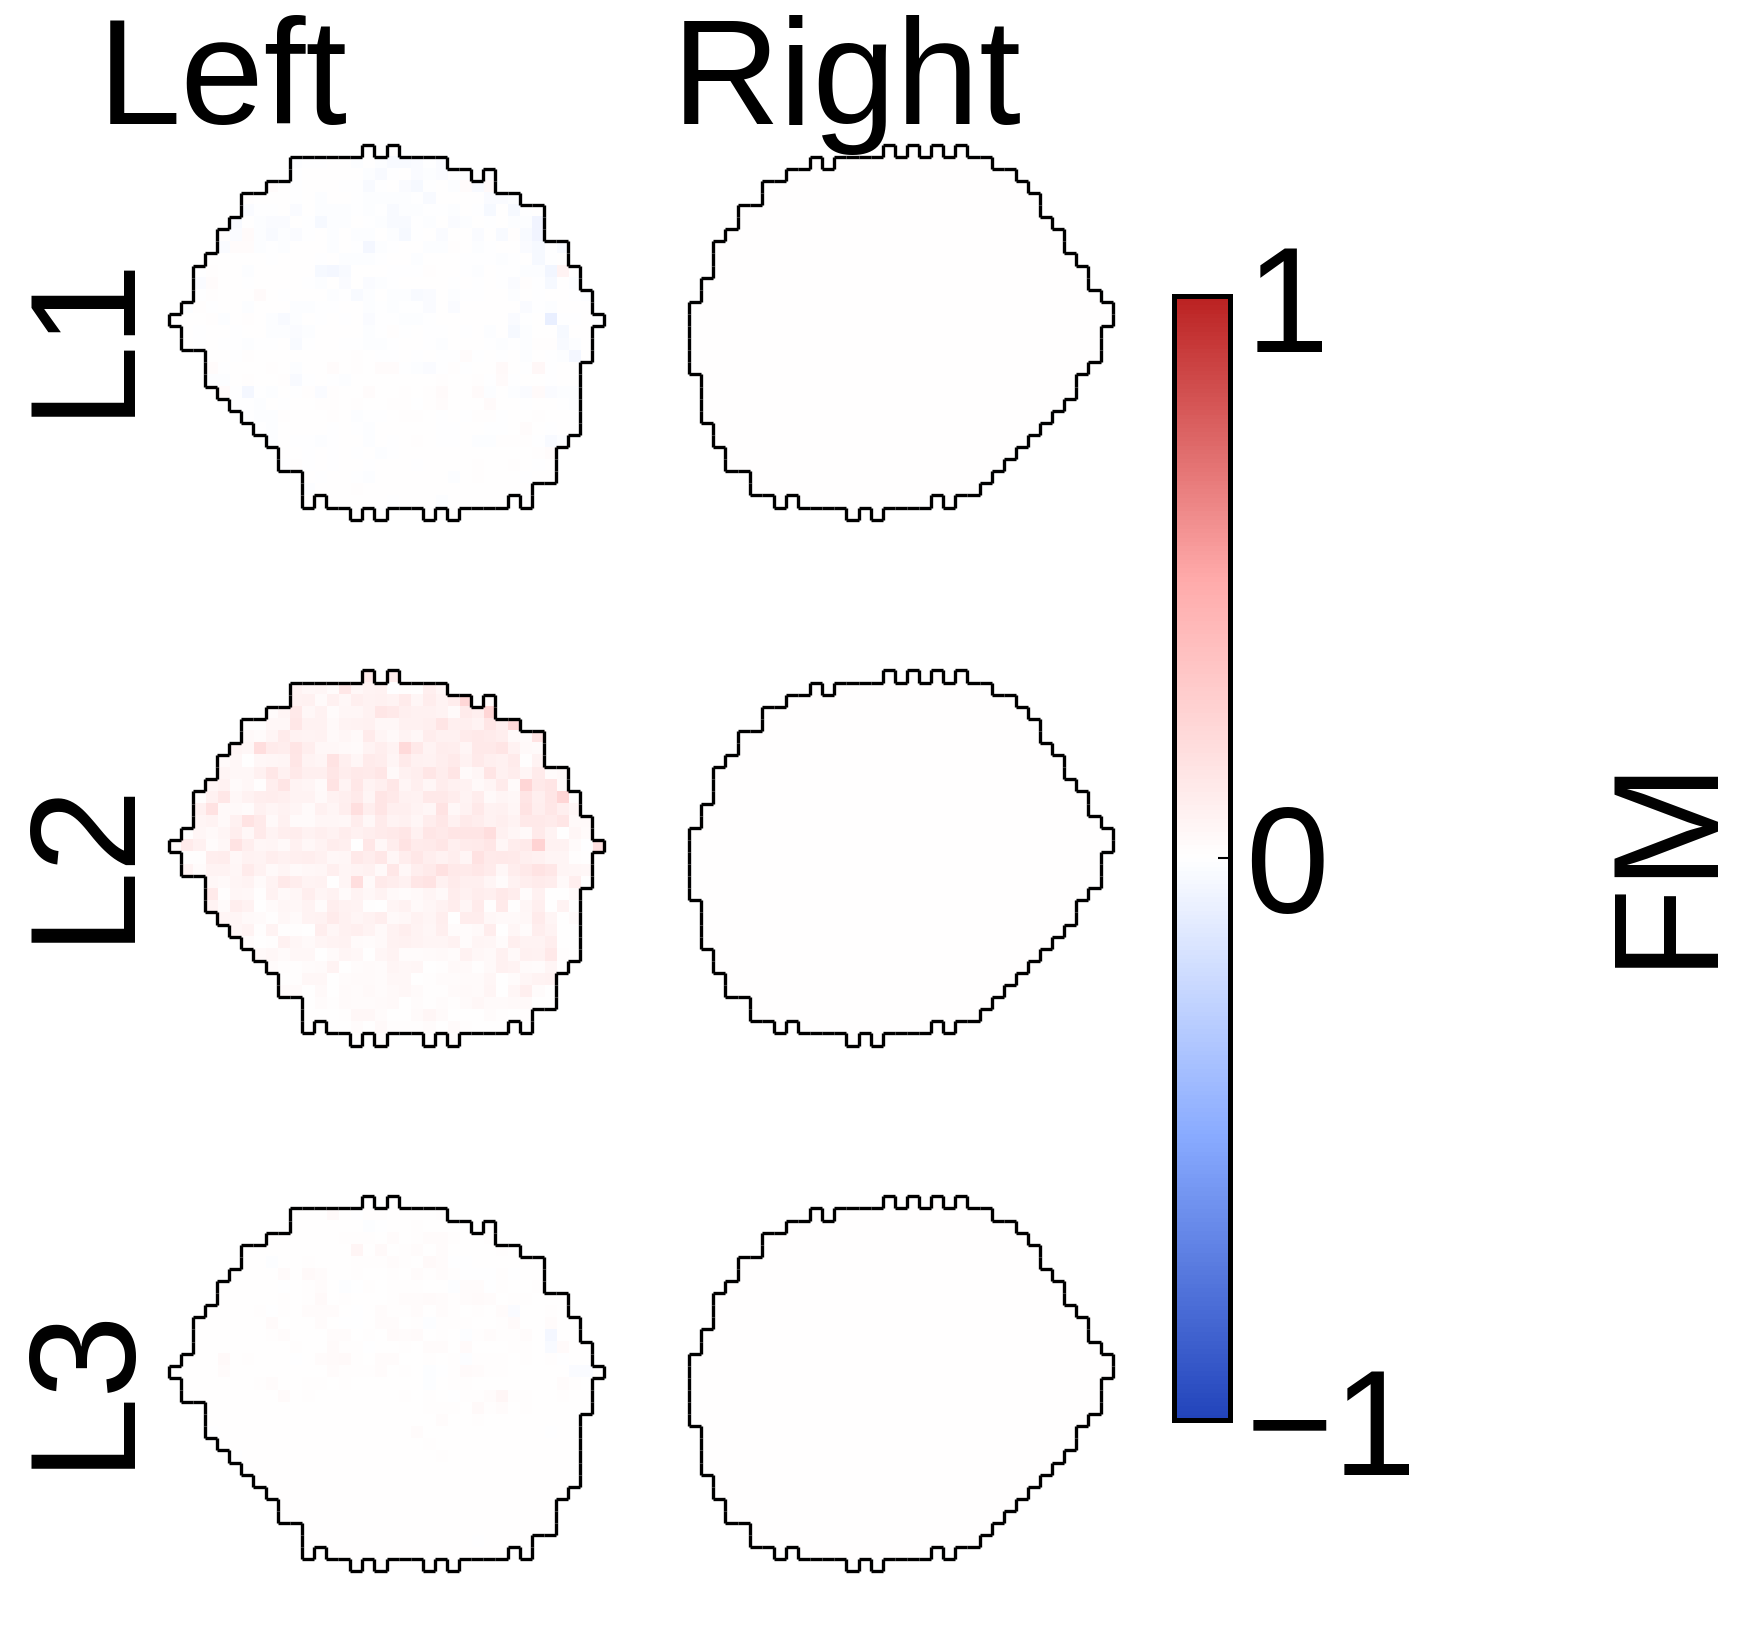

In [ ]:
vfm_show = VFMShow("../data/column_assignment.txt")

neuron_ids = [720575940622838154]
for neuron_id in neuron_ids:
    
    vfm_show.plot_single_neuron_all_layers(neuron_id=neuron_id, normalize=True)

In [ ]:
analyzer.export_combined_summary_csv(
    side="left",
    neuron_types=["L1","L2","L3"],
    pos_npz_paths=[
        "preprocess/l1_left_excitatory.npz",
        "preprocess/l2_left_excitatory.npz",
        "preprocess/l3_left_excitatory.npz"
    ],
    neg_npz_paths=[
        "preprocess/l1_left_inhibitory.npz",
        "preprocess/l2_left_inhibitory.npz",
        "preprocess/l3_left_inhibitory.npz"
    ],
    cell_type_path="../data/cell_type.txt",
    preprocess_csv="./preprocess/visual_left_weight_summary.csv"
)
analyzer.export_combined_summary_csv(
    side="right",
    neuron_types=["L1","L2","L3"],
    pos_npz_paths=[
        "preprocess/l1_right_excitatory.npz",
        "preprocess/l2_right_excitatory.npz",
        "preprocess/l3_right_excitatory.npz"
    ],
    neg_npz_paths=[
        "preprocess/l1_right_inhibitory.npz",
        "preprocess/l2_right_inhibitory.npz",
        "preprocess/l3_right_inhibitory.npz"
    ],
    cell_type_path="../data/cell_type.txt",
    preprocess_csv="./preprocess/visual_right_weight_summary.csv"
)

Combined summary saved to ./preprocess/visual_left_weight_summary.csv
Combined summary saved to ./preprocess/visual_right_weight_summary.csv


In [ ]:
analyzer = FMAnalyzer(
    matrix_npz_path="./preprocess/connectome_matrix.npz",
    neuron_ids_path="./preprocess/neuron_ids.npy",
    neuron_types_path="../data/visual_neuron_types.txt"
)
# ---------------------------
# Function to read neuron IDs by type
# ---------------------------
P9_oDN1_left = 720575940626730883
P9_oDN1_right = 720575940620300308
P9_left = 720575940627652358
P9_right = 720575940635872101

DNa01_right = 720575940627787609
DNa01_left = 720575940644438551
DNa02_right = 720575940629327659
DNa02_left = 720575940604737708

MDN_1, MDN_2, MDN_3, MDN_4 = 720575940616026939, 720575940631082808, 720575940640331472, 720575940610236514

Giant_Fiber_1, Giant_Fiber_2 = 720575940622838154, 720575940632499757

MN9_left = 720575940660219265
MN9_right = 720575940618238523

aDN1_right = 720575940616185531
aDN1_left = 720575940624319124

behavior_neurons = [
    P9_oDN1_left, P9_oDN1_right, P9_left, P9_right,
    DNa01_right, DNa01_left, DNa02_right, DNa02_left,
    MDN_1, MDN_2, MDN_3, MDN_4,
    Giant_Fiber_1, Giant_Fiber_2,
    MN9_left, MN9_right,
    aDN1_right, aDN1_left
]

sugar_GRNs = [720575940616885538,720575940630233916,720575940639332736,720575940632889389,720575940617000768,720575940632425919,720575940637568838,720575940629176663,720575940621502051,720575940638202345,720575940612670570,720575940611875570,720575940621754367,720575940633143833,720575940613601698,720575940630797113,720575940639198653,720575940639259967,720575940624963786,720575940640649691,720575940610788069,720575940623172843,720575940628853239]

bitter_GRNs = [720575940619072513,720575940646212996,720575940622298631,720575940642088333,720575940627692048,720575940617239197,720575940618682526,
               720575940604714528,720575940603266592,720575940604027168,720575940619197093,720575940610259370,720575940627578156,720575940629481516,
               720575940618887217,720575940614281266,720575940634859188,720575940645743412,720575940637742911,720575940617094208,720575940629416318,
               720575940630195909,720575940615641798,720575940638312262,720575940624310345,720575940621778381,720575940619659861,720575940629146711,
               720575940625750105,720575940610483162,720575940610481370,720575940602353632,720575940610773090,720575940617433830,720575940628962407,
               720575940626287336,720575940623183083,720575940618025199,720575940619028208,720575940621864060,720575940613061118,720575940621008895,]
LC_4s =[720575940605598892,720575940611134833,720575940612580977,720575940613256863,720575940613260959,720575940614914107,720575940615462587,720575940617176321,720575940617266722,720575940618807105,720575940620795728,720575940622108001,720575940624017251,720575940625038090,720575940625934973,720575940625991043,720575940626605200,720575940626626895,720575940628454522,720575940628462340,720575940630851036,720575940638496720,720575940603637438,720575940610522009,720575940612093351,720575940612323025,720575940612380723,720575940612498129,720575940612518055,720575940612968421,720575940613609484,720575940613638041,720575940614572742,720575940614582946,720575940615053580,720575940615127227,720575940615232217,720575940615575007,720575940616066705,720575940616713355,720575940617026260,720575940617348379,720575940618002644,720575940618234704,720575940618234715,720575940618266459,720575940618267227,720575940618275520,720575940618312606,720575940618676440,720575940618709158,720575940618723749,720575940619397542,720575940620314221,720575940620314612,720575940620731380,720575940620903551,720575940621145821,720575940621522458,720575940621753579,720575940622330582,720575940622531767,720575940622939836,720575940624111763,720575940624790781,720575940624856762,720575940625841351,720575940625845447,720575940625906702,720575940625932421,720575940626553596,720575940626916936,720575940627519107,720575940628064260,720575940628081541,720575940628419527,720575940628518400,720575940628599895,720575940628606713,720575940628699560,720575940628891863,720575940629753807,720575940629964591,720575940630154660,720575940630484495,720575940630998339,720575940631032657,720575940631338271,720575940632475449,720575940632715234,720575940632769180,720575940633013355,720575940633218863,720575940633580384,720575940634517856,720575940635835967,720575940636957006,720575940638456227,720575940639817947,720575940640612480,720575940641213824,720575940645821316,720575940649229433,720575940652611745]

JO_EV = [720575940645106376,720575940615272415,720575940619869120,720575940620257345,720575940620382889,720575940630834683,720575940632449619,720575940634020508,720575940605530302,720575940607140035,720575940608742409,720575940615590843,720575940620410177,
         720575940621870618,720575940622344170,720575940623298559,720575940626042149,720575940627379333,720575940630080071,720575940632128031,
         720575940632307527,720575940634820703,]
JO_EDC=[720575940606154370,720575940605919334,720575940608884931,720575940616655989,720575940620543110,720575940622937528,720575940624799290,
        720575940626565455,720575940627941431,720575940627977457,
        720575940628160617,720575940629188251,720575940641921421]
JO_EDM=[720575940615972027,720575940618941037,720575940619729835,720575940627282279,720575940628903247,720575940604122982,720575940609486690,
        720575940609541917,
        720575940610018266,720575940611061526,720575940611273395,720575940611684787,720575940614060829,720575940616040587,720575940618599872,
        720575940618684481,720575940619663239,720575940619932654,720575940620919578,720575940621218729,720575940622271684,720575940622638276,
        720575940623312828,720575940625797617,720575940625962568,720575940626309438,720575940626666066,720575940627109991,720575940628101126,
        720575940628978450,720575940629055721,720575940629650997,720575940629985900,720575940630992557,720575940637054835,720575940637084762,
        720575940638664437,720575940646927668,720575940646929204,720575940659131009]
JO_EDP=[720575940609522461,720575940610261346,720575940613641915,720575940615469785,720575940616589878,720575940616951124,720575940619479979,
        720575940621218985,720575940628444667,720575940634634606,720575940640753267,720575940650244342]
JO_EVL=[720575940615573597,720575940615848788,720575940619083349,720575940621397417,720575940621625597,720575940622283912,720575940627049731,
        720575940629022149,720575940630122015,720575940630564179,720575940633153375,720575940637410869,720575940638681845,720575940621033477,
        720575940621776410,720575940621815690,720575940622234211,720575940622635817,720575940623897096,720575940626148354,720575940626540821,
        720575940628258715,720575940629743063,720575940630202624,720575940630544967,720575940633553820,720575940644036644]
JO_EVM=[720575940602132509,720575940602506208,720575940610759634,720575940614188149,720575940615809349,720575940615976891,720575940619341105,
        720575940621092534,720575940622419165,720575940622449388,720575940623108134,720575940624981436,720575940628192055,720575940630059847,
        720575940632767383,720575940639296189,720575940645466500,720575940611783464,720575940612307478,720575940612960552,720575940614351477,
        720575940617212134,720575940617434086,720575940618130334,720575940620249734,720575940620940276,720575940621010352,720575940621729757,
        720575940623437547,720575940624546062,720575940624686268,720575940625054647,720575940625605905,720575940626795909,720575940627585688,
        720575940630020111,720575940632175268,720575940634073183,720575940634891700,720575940637012196,720575940637243504,720575940639339392,
        720575940659426177]
JO_EVP=[720575940620444654,720575940631866508,720575940607853833,720575940611088563,720575940612773374,720575940613221928,720575940615024543,720575940615986459,720575940617811013,720575940618467195,720575940621442224,
        720575940622199977,720575940624915230,720575940625559358,720575940627104649,720575940627314088,720575940633058989,720575940636335735]
JO_CA=[720575940605800369,720575940608784579,720575940618135109,720575940626719101,720575940629296185,720575940636137591,720575940602720940,720575940610079857,720575940614427195,720575940616501787,720575940617156445,720575940625909962,720575940626241369,720575940629105658,720575940629138959,720575940636559534,720575940641372661]
JO_CL=[720575940626135548,720575940627751567,720575940604753437,720575940613971485,720575940614835362,720575940623399059,720575940630319671,720575940639082062]
JO_CM=[720575940607386307,720575940634512992,720575940614035485,720575940618901424,720575940630070343,720575940633443353,720575940635058612,720575940637632419,720575940625626000]
all_JOs = JO_EV+JO_EDC+JO_EDM+JO_EDP+JO_EVL+JO_EVM+JO_EVP+JO_CA+JO_CL+JO_CM

LC_9 = [720575940631199744,720575940616721921,720575940618735105,720575940625971204,720575940624330254,720575940629300242,720575940642959895,720575940643039255,720575940644095511,720575940622162456,720575940617432603,720575940645023268,720575940627941931,720575940629791275,720575940632949807,720575940624856112,720575940624624176,720575940617678897,720575940617922097,720575940647603252,720575940644686388,720575940616492096,720575940614030914,720575940628858954,720575940629419594,720575940626397258,720575940627180618,720575940640440910,720575940631711225,720575940631148113,720575940617836117,720575940614766166,720575940638793304,720575940635986522,720575940617467485,720575940624273508,720575940635294309,720575940604681830,720575940604922982,720575940628237415,720575940612942442,720575940634228843,720575940644843118,720575940610002033,720575940613370482,720575940615517813,720575940634336887,720575940650416249,720575940648290937,720575940628875902,720575940606423170,720575940625607811,720575940606087298,720575940626005641,720575940626451081,720575940625232009,720575940626594447,720575940614303890,720575940610902165,720575940610421913,720575940620130462,720575940642995360,720575940612627106,720575940615522978,720575940630788772,720575940630642861,720575940605020337,720575940617284283,720575940616883387,720575940627841730,720575940609860803,720575940624339652,720575940609454798,720575940628679887,720575940612258513,720575940631357651,720575940631486163,720575940608166101,720575940620435158,720575940629594839,720575940620696280,720575940617486552,720575940605318880,720575940603944672,720575940632603873,720575940612021475,720575940636760292,720575940634073825,720575940638976233,720575940622341354,720575940612617453,720575940619613422,720575940619410671,720575940619529455,720575940610825458,720575940634545400,720575940622964477,720575940616677121,720575940615893249,720575940626456330,720575940621001485,720575940623047438,720575940626566931,720575940625777941,720575940625746709,720575940620542746,720575940616204059,720575940618930459,720575940622345215,720575940620827425,720575940617253666,720575940620982049,720575940628972332,720575940630865197,720575940625127728,720575940619643190,720575940615012667,720575940624082238,720575940636056895,720575940636178239,720575940630162755,720575940628347722,720575940630247243,720575940625045837,720575940628654927,720575940626475858,720575940618046292,720575940620821333,720575940617878869,720575940628908375,720575940624740185,720575940636759386,720575940606521180,720575940607313756,720575940621440862,720575940632619880,720575940626613609,720575940634140011,720575940629470572,720575940635224943,720575940613481330,720575940620178299,720575940622285183,720575940661191041,720575940658141057,720575940625390979,720575940624319880,720575940627814281,720575940616565131,720575940635970446,720575940625772943,720575940616386449,720575940615061906,720575940621506451,720575940622457235,720575940634186647,720575940625809816,720575940635689370,720575940652785057,720575940619163045,720575940622008230,720575940612354983,720575940626803624,720575940617978789,720575940618541995,720575940612224943,720575940635376052,720575940623073205,720575940626615738,720575940615238075,720575940614135739,720575940637379517,720575940619434432,720575940614775238,720575940624070090,720575940624069578,720575940631379449,720575940609523662,720575940628889551,720575940639459280,720575940628337103,720575940610230738,720575940607839189,720575940621415382,720575940615480281,720575940616215513,720575940635703262,720575940632214497,720575940616522726,720575940619676654,720575940621585903,720575940619601392,720575940628261873,720575940619788276,720575940619719668,720575940639201269,720575940629549049,720575940621352447]

Ir94e = [720575940612920386,720575940626241636,720575940628198503,720575940631082124,720575940626016017,720575940610683315,720575940621375231,720575940624079544,720575940615274425,720575940638218173,720575940614211295]

Water = [720575940612950568,720575940631898285,720575940606002609,720575940612579053,720575940622902535,
  720575940616177458,720575940660292225,720575940622486922,720575940613786774,720575940629852866,
  720575940625861168,720575940613996959,720575940617857694,720575940644965399,720575940625203504,
  720575940630553415,720575940635172191,720575940634796536]
LC_16_L = [720575940618566657,720575940620512261,720575940614680076,720575940623429645,720575940627100176,720575940622419480,720575940604337696,720575940622693414,720575940631233581,720575940624412222,720575940621535809,720575940637662790,720575940638927960,720575940621623393,720575940625307748,720575940634916453,720575940634188907,720575940630538362,720575940628499582,720575940645700228,720575940622253704,720575940622018698,720575940618160273,720575940624226963,720575940623143060,720575940610397845,720575940615860886,720575940633246399,720575940629996741,720575940641607888,720575940609602770,720575940610152661,720575940632496865,720575940633360610,720575940632108257,720575940611607779,720575940611787493,720575940619646191,720575940620238576,720575940650937078,720575940628513015,720575940612946686,720575940627030790,720575940627179270,720575940619272980,720575940622202150,720575940622319913,720575940628995884,720575940630914863,720575940631576367,720575940614341938,720575940613068083,720575940647966004,720575940618445622,720575940630308163,720575940624021325,720575940637952846,720575940634780517,720575940620490093,720575940630357886,720575940628545406,720575940640228736,720575940607924098,720575940626371465,720575940626542985,720575940614082966,720575940614402966,720575940635559322,720575940621608363,720575940623368629,720575940623179703,720575940604749758,720575940603452384,720575940613261795,720575940626462184,720575940637073897,720575940619663343,720575940626742769]
LC_16_R = [720575940629640960,720575940617374465,720575940638540672,720575940605242242,720575940627066884,720575940628456196,720575940620996357,720575940626517129,720575940625648009,720575940617063436,720575940627874832,720575940624123536,720575940615124370,720575940626148371,720575940619317524,720575940622962579,720575940625871768,720575940638881699,720575940644440100,720575940622084774,720575940622014758,720575940628309160,720575940628308904,720575940628309416,720575940613168554,720575940631230508,720575940610893738,720575940613540527,720575940614376498,720575940614712115,720575940636471220,720575940617990454,720575940630883897,720575940624140732,720575940640231485,720575940624593982,720575940640218941,720575940606173630,720575940619646913,720575940608490435,720575940637645894,720575940631086151,720575940607361481,720575940631414223,720575940641251792,720575940611945170,720575940626463570,720575940615989972,720575940631153491,720575940621425878,720575940626611026,720575940618798040,720575940618214360,720575940618030429,720575940636087006,720575940614646495,720575940614702815,720575940621548897,720575940634821733,720575940637448681,720575940624983531,720575940629493356,720575940613710061,720575940614582765,720575940620642287,720575940612201586,720575940623026419,720575940620443508,720575940623969779,720575940631124598,720575940631165814,720575940648637049,720575940618057595,720575940628789374]

source_ids = sugar_GRNs+bitter_GRNs+LC_4s+all_JOs+Water+LC_9+LC_16_L+LC_16_R

analyzer.compute_weights_by_ids(
    source_ids=source_ids,
    target_ids=behavior_neurons,
    max_depth=100,
    min_weight=1e-6,
    num_processes=256,
    save_prefix='Behavior_Neurons'
)

Processing sources: 100%|██████████| 746/746 [00:50<00:00, 14.66it/s]


Results saved to ./preprocess/Behavior_Neurons_excitatory.npz and ./preprocess/Behavior_Neurons_inhibitory.npz


(array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         2.54507101e-05, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         6.07589159e-06, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         6.68363157e-06, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.02414988e-06, 1.02693411e-06, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]], shape=(746, 18)),
 array([[-1.10026019e-06,  0.00000000e+00,  0.00000000e+00, ...,
         -2.06201259e-05,  0.00000000e+00,  0.00000000e+00],
        [-1.41462024e-06,  0.00000000e+00,  0.00000000e+00, ...,
         -3.78377946e-06,  0.00000000e+00,  0.00000000e+0